# Tahap 1: Membaca Data dan Cleaning Awal

Notebook ini melanjutkan hasil data audit. Target model adalah `price`, sehingga project ini diperlakukan sebagai problem regression.

Baris dengan `price` missing tidak dapat digunakan untuk supervised training karena nilai targetnya tidak diketahui. Pada tahap ini juga dilakukan pengecekan nilai tidak valid seperti `distance <= 0` dan `price <= 0`.

File raw di dalam `data/raw/` tetap dibiarkan apa adanya. Data hasil cleaning disimpan terpisah di `data/processed/`.


In [1]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
elif not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from preprocessing import (
    build_preprocessor,
    clean_cab_rides,
    create_time_features,
    get_feature_target,
    load_raw_data,
)
from train_model import (
    evaluate_model,
    save_model,
    train_baseline_models,
    train_test_split_data,
)

raw_path = project_root / "data" / "raw" / "cab_rides.csv"
processed_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
processed_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

cleaned_path = processed_dir / "cleaned_cab_rides.csv"
model_path = models_dir / "baseline_price_model.joblib"

print("Project root:", project_root)
print("Raw data path:", raw_path)


Project root: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online
Raw data path: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\data\raw\cab_rides.csv


In [2]:
cab_rides = load_raw_data(raw_path)
rows_before_cleaning = len(cab_rides)

print("Shape before cleaning:", cab_rides.shape)
display(cab_rides.head())


Shape before cleaning: (693071, 10)


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [3]:
missing_price_rows = int(cab_rides["price"].isna().sum())

without_missing_price = cab_rides.dropna(subset=["price"]).copy()
invalid_distance_rows = int((without_missing_price["distance"] <= 0).sum())

without_invalid_distance = without_missing_price[without_missing_price["distance"] > 0].copy()
invalid_price_rows = int((without_invalid_distance["price"] <= 0).sum())

without_invalid_price = without_invalid_distance[without_invalid_distance["price"] > 0].copy()
duplicate_rows = int(without_invalid_price.duplicated().sum())

cleaned_cab_rides = clean_cab_rides(cab_rides)
rows_after_cleaning = len(cleaned_cab_rides)

cleaned_cab_rides.to_csv(cleaned_path, index=False)

cleaning_summary = pd.DataFrame({
    "Cleaning Step": [
        "Rows before cleaning",
        "Rows with missing price removed",
        "Rows with distance <= 0 removed",
        "Rows with price <= 0 removed",
        "Duplicate rows removed",
        "Rows after cleaning",
    ],
    "Count": [
        rows_before_cleaning,
        missing_price_rows,
        invalid_distance_rows,
        invalid_price_rows,
        duplicate_rows,
        rows_after_cleaning,
    ],
})

display(cleaning_summary)
print(f"Cleaned data saved to: {cleaned_path}")


,Cleaning Step,Count
0,Rows before cleaning,693071
1,Rows with missing price removed,55095
2,Rows with distance <= 0 removed,0
3,Rows with price <= 0 removed,0
4,Duplicate rows removed,0
5,Rows after cleaning,637976


Cleaned data saved to: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\data\processed\cleaned_cab_rides.csv


# Tahap 2: Pemilihan Fitur dan Feature Engineering

Model memprediksi `price` sebagai nilai tarif numerik, sehingga tugasnya adalah regression. Baseline model hanya menggunakan fitur dari data perjalanan.

Fitur yang digunakan adalah `distance`, `cab_type`, `source`, `destination`, `name`, `hour`, `day`, `month`, dan `day_of_week`.

Kolom yang dikeluarkan dari baseline utama adalah `id`, `product_id`, `price`, dan `surge_multiplier`. `id` dan `product_id` adalah identifier, `price` adalah target, sedangkan `surge_multiplier` dikeluarkan karena terlalu dekat dengan mekanisme pricing.


In [4]:
model_data = create_time_features(cleaned_cab_rides)

time_preview_columns = ["time_stamp", "datetime", "hour", "day", "month", "day_of_week"]
display(model_data[time_preview_columns].head())


,time_stamp,datetime,hour,day,month,day_of_week
0,1544952607890,2018-12-16 09:30:07.890,9,16,12,6
1,1543284023677,2018-11-27 02:00:23.677,2,27,11,1
2,1543366822198,2018-11-28 01:00:22.198,1,28,11,2
3,1543553582749,2018-11-30 04:53:02.749,4,30,11,4
4,1543463360223,2018-11-29 03:49:20.223,3,29,11,3


In [5]:
X, y, feature_columns, numeric_features, categorical_features = get_feature_target(
    model_data,
    include_surge=False,
)

target_column = "price"

print("Selected feature columns:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget column:", target_column)
print("X shape:", X.shape)
print("y shape:", y.shape)


Selected feature columns:
- distance
- cab_type
- source
- destination
- name
- hour
- day
- month
- day_of_week

Target column: price
X shape: (637976, 9)
y shape: (637976,)


In [6]:
feature_group_summary = pd.DataFrame({
    "Feature Group": ["Numerical", "Categorical"],
    "Columns": [", ".join(numeric_features), ", ".join(categorical_features)],
})

display(feature_group_summary)
display(X.head())


,Feature Group,Columns
0,Numerical,"distance, hour, day, month, day_of_week"
1,Categorical,"cab_type, source, destination, name"


,distance,cab_type,source,destination,name,hour,day,month,day_of_week
0,0.44,Lyft,Haymarket Square,North Station,Shared,9,16,12,6
1,0.44,Lyft,Haymarket Square,North Station,Lux,2,27,11,1
2,0.44,Lyft,Haymarket Square,North Station,Lyft,1,28,11,2
3,0.44,Lyft,Haymarket Square,North Station,Lux Black XL,4,30,11,4
4,0.44,Lyft,Haymarket Square,North Station,Lyft XL,3,29,11,3


# Tahap 3: Membuat Preprocessing Pipeline

Preprocessing diperlukan karena model machine learning tidak dapat langsung membaca kategori teks seperti jenis layanan, lokasi asal, tujuan, dan nama layanan.

Fitur numerik diproses dengan scaler, sedangkan fitur kategorikal diubah menjadi kolom numerik menggunakan one-hot encoding. Pipeline ini penting dalam MLOps karena transformasi yang sama dapat dipakai ulang saat training dan prediction.


In [7]:
preprocessor = build_preprocessor(numeric_features, categorical_features, scale_numeric=True)

preprocessing_summary = pd.DataFrame({
    "Column Type": ["Numerical", "Categorical"],
    "Columns": [", ".join(numeric_features), ", ".join(categorical_features)],
    "Transformation": ["StandardScaler", "OneHotEncoder(handle_unknown='ignore')"],
})

display(preprocessing_summary)
print("Reusable preprocessing logic saved in:", project_root / "src" / "preprocessing.py")
preprocessor


,Column Type,Columns,Transformation
0,Numerical,"distance, hour, day, month, day_of_week",StandardScaler
1,Categorical,"cab_type, source, destination, name",OneHotEncoder(handle_unknown='ignore')


Reusable preprocessing logic saved in: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\src\preprocessing.py


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

# Tahap 4: Melatih Baseline Regression Models

Baseline model digunakan untuk mendapatkan hasil awal yang terukur. Pada notebook ini, model yang dibandingkan adalah `DummyRegressor`, `Ridge Regression`, dan `Random Forest Regressor`.

Training ini adalah simulasi pembelajaran untuk mini project MLOps, bukan sistem pricing produksi nyata.


In [8]:
X_train, X_test, y_train, y_test = train_test_split_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training feature shape: (510380, 9)
Testing feature shape: (127596, 9)
Training target shape: (510380,)
Testing target shape: (127596,)


In [9]:
trained_models = train_baseline_models(
    preprocessor,
    X_train,
    y_train,
    random_state=42,
    rf_sample_size=100_000,
)

models_trained = list(trained_models.keys())

print("Models trained:")
for model_name in models_trained:
    print("-", model_name)

print("\nReusable training logic saved in:", project_root / "src" / "train_model.py")


Models trained:
- Dummy Regressor
- Ridge Regression
- Random Forest Regressor

Reusable training logic saved in: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\src\train_model.py


# Tahap 5: Evaluasi Hasil Baseline

Karena target berbentuk numerik, evaluasi menggunakan metrik regression: MAE, RMSE, dan R2 Score.

Hasil evaluasi ini menjadi dasar CT checklist pada tahap berikutnya.


In [10]:
evaluation_results = []

for model_name, model in trained_models.items():
    metrics = evaluate_model(model, X_test, y_test)
    evaluation_results.append({
        "Model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2 Score": metrics["R2 Score"],
    })

results_df = pd.DataFrame(evaluation_results).sort_values("MAE").reset_index(drop=True)
display(results_df)


,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,1.425413,2.618088,9.213770e-01
1,Ridge Regression,1.928243,3.037824,8.941462e-01
2,Dummy Regressor,7.559787,9.337046,-1.455636e-07


In [11]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_metrics = results_df.loc[0].to_dict()

save_model(best_model, model_path)

print("Best model selected by lowest MAE:", best_model_name)
print(f"MAE: {best_metrics['MAE']:.4f}")
print(f"RMSE: {best_metrics['RMSE']:.4f}")
print(f"R2 Score: {best_metrics['R2 Score']:.4f}")
print("Saved model path:", model_path)


Best model selected by lowest MAE: Random Forest Regressor
MAE: 1.4254
RMSE: 2.6181
R2 Score: 0.9214
Saved model path: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\models\baseline_price_model.joblib


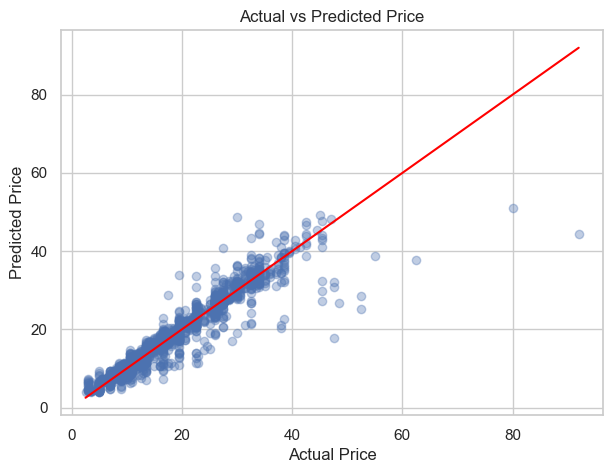

In [12]:
plot_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
actual_values = y_test.loc[plot_sample.index]
predicted_values = best_model.predict(plot_sample)

plt.figure(figsize=(7, 5))
plt.scatter(actual_values, predicted_values, alpha=0.35)
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], color="red")
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()


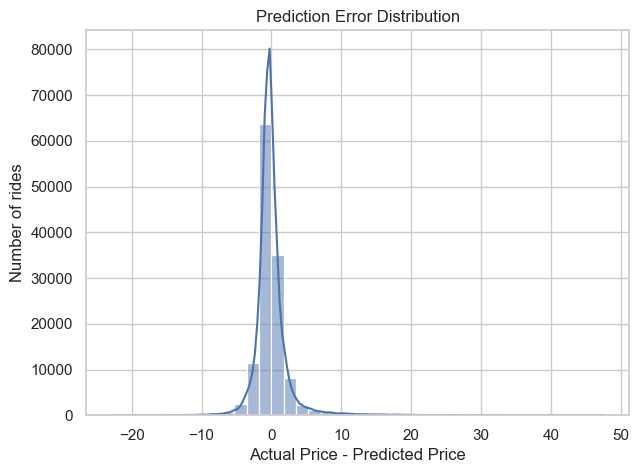

In [13]:
all_predictions = best_model.predict(X_test)
residuals = y_test - all_predictions

plt.figure(figsize=(7, 5))
if HAS_SEABORN:
    sns.histplot(residuals, bins=40, kde=True)
else:
    plt.hist(residuals, bins=40, edgecolor="black")
plt.title("Prediction Error Distribution")
plt.xlabel("Actual Price - Predicted Price")
plt.ylabel("Number of rides")
plt.show()


In [14]:
final_summary = pd.DataFrame({
    "Item": [
        "Rows before cleaning",
        "Rows after cleaning",
        "Features used",
        "Target column",
        "Models trained",
        "Best model name",
        "MAE",
        "RMSE",
        "R2 Score",
        "Saved model path",
    ],
    "Value": [
        f"{rows_before_cleaning:,}",
        f"{rows_after_cleaning:,}",
        ", ".join(feature_columns),
        target_column,
        ", ".join(models_trained),
        best_model_name,
        f"{best_metrics['MAE']:.4f}",
        f"{best_metrics['RMSE']:.4f}",
        f"{best_metrics['R2 Score']:.4f}",
        str(model_path),
    ],
})

display(final_summary)

print("Final summary")
for _, row in final_summary.iterrows():
    print(f"{row['Item']}: {row['Value']}")


,Item,Value
0,Rows before cleaning,"693,071"
1,Rows after cleaning,"637,976"
2,Features used,"distance, cab_type, source, destination, name,..."
3,Target column,price
4,Models trained,"Dummy Regressor, Ridge Regression, Random Fore..."
5,Best model name,Random Forest Regressor
6,MAE,1.4254
7,RMSE,2.6181
8,R2 Score,0.9214
9,Saved model path,d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops...


Final summary
Rows before cleaning: 693,071
Rows after cleaning: 637,976
Features used: distance, cab_type, source, destination, name, hour, day, month, day_of_week
Target column: price
Models trained: Dummy Regressor, Ridge Regression, Random Forest Regressor
Best model name: Random Forest Regressor
MAE: 1.4254
RMSE: 2.6181
R2 Score: 0.9214
Saved model path: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\models\baseline_price_model.joblib


# Ringkasan Tahap 2

- Data berhasil dibersihkan tanpa memodifikasi file raw.
- Fitur waktu berhasil dibuat dari `time_stamp`.
- Baseline model berhasil dilatih menggunakan fitur data perjalanan saja.
- Model yang dibandingkan adalah Dummy Regressor, Ridge Regression, dan Random Forest Regressor.
- Random Forest Regressor menjadi model terbaik dengan MAE 1.4254, RMSE 2.6181, dan R2 Score 0.9214.
- Hasil model digunakan untuk tahap evaluasi.
